In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/ab-test.csv')
df.head()

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test


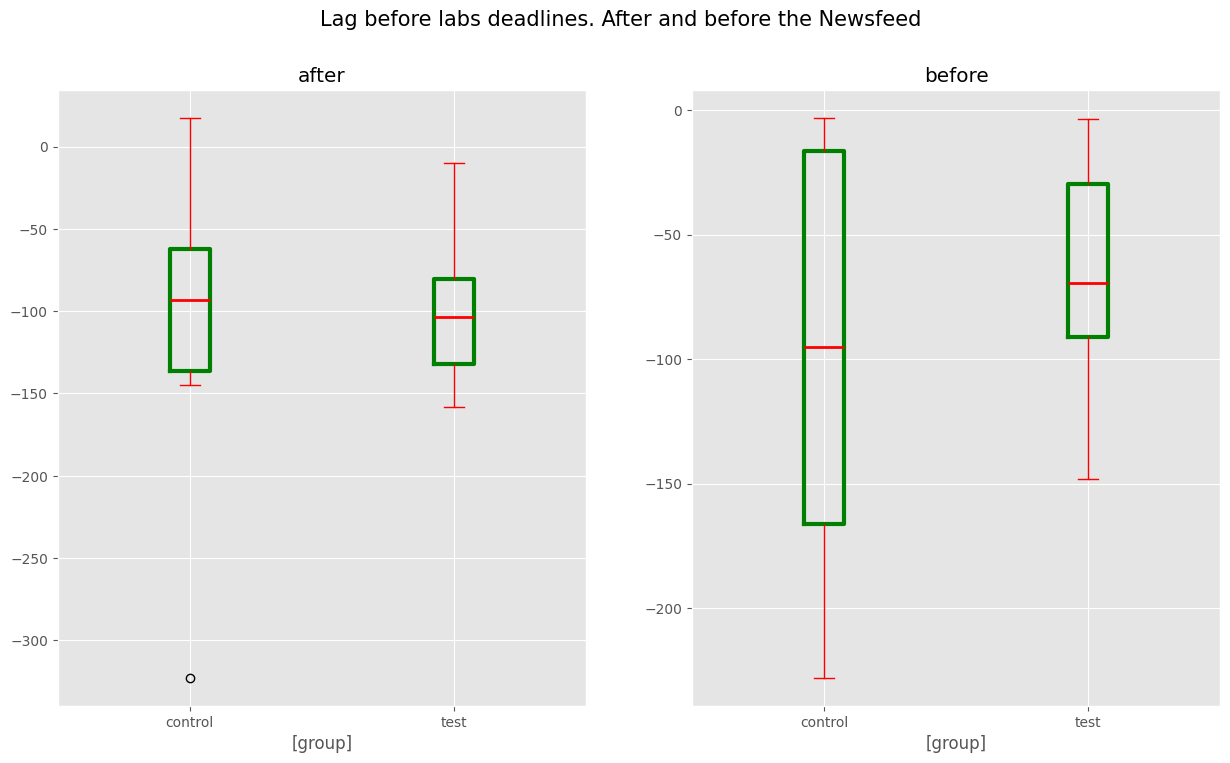

In [3]:
df_after = df[df['time'] == 'after']
df_before = df[df['time'] == 'before']

plt.style.use('ggplot')
fig, axs = plt.subplots(1, 2, figsize=(15, 8))

boxprops = dict(linewidth=3, color='green')
medianprops = dict(linewidth=2, color='red')
whiskerprops = dict(color='red')
capprops = dict(color='red')

axs[0].boxplot(
    [df_after[df_after['group'] == 'control']['diff'], 
     df_after[df_after['group'] == 'test']['diff']],
    tick_labels=['control', 'test'],
    patch_artist=False,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
)
axs[0].set_title('after')
axs[0].set_xlabel('[group]')

axs[1].boxplot(
    [df_before[df_before['group'] == 'control']['diff'], 
     df_before[df_before['group'] == 'test']['diff']],
    tick_labels=['control', 'test'],
    patch_artist=False,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
)
axs[1].set_title('before')
axs[1].set_xlabel('[group]')

fig.suptitle('Lag before labs deadlines. After and before the Newsfeed', fontsize=15)
plt.show()

## Control group before IQR 150